In [1]:
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")
%env PYTHONWARNINGS=ignore
%env JUPYTER_PLATFORM_DIRS=1

env: PYTHONWARNINGS=ignore
env: JUPYTER_PLATFORM_DIRS=1


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neighbors import LocalOutlierFactor

import mlflow

from feast import FeatureStore

# Setting the warnings to be ignore once again after all the importing
import logging
warnings.filterwarnings("ignore")
logging.getLogger("mlflow").setLevel(logging.ERROR)

# Set the seed for reproducibility
np.random.seed(42)

In [3]:
# Set MLflow tracking URI
mlflow.set_tracking_uri("http://localhost:5000/")

# Set up MLflow experiment
mlflow.set_experiment("Poison_Level_Analysis")

<Experiment: artifact_location='mlflow-artifacts:/976554620520818858', creation_time=1754412708816, experiment_id='976554620520818858', last_update_time=1754412708816, lifecycle_stage='active', name='Poison_Level_Analysis', tags={}>

In [4]:
# Initialize the Feast feature store
# This connects to the pre-configured feature repository
store = FeatureStore(repo_path="Iris_Feast/feature_repo")

In [5]:
# Load entity dataframe with timestamps for historical feature retrieval
entity_df = pd.read_csv("data/entity.csv", parse_dates=['event_timestamp'])

# Retrieve historical features using Feast
# This gets features at specific points in time for training
data = store.get_historical_features(
    entity_df=entity_df,
    features=store.get_feature_service("feast_model_v1")
).to_df()

# Display first 10 rows of the dataset
print("First 10 rows of the dataset:")
data.head(10)

First 10 rows of the dataset:


,species,event_timestamp,sepal_length,sepal_width,petal_length,petal_width
0,setosa,2025-06-21 20:12:06.043098+00:00,5.4,3.7,1.5,0.2
1,setosa,2025-06-21 21:17:06.043098+00:00,5.1,3.3,1.7,0.5
2,setosa,2025-06-21 20:42:06.043098+00:00,5.4,3.9,1.3,0.4
3,setosa,2025-06-21 22:42:06.043098+00:00,5.0,3.5,1.3,0.3
4,setosa,2025-06-21 20:17:06.043098+00:00,4.8,3.4,1.6,0.2
5,setosa,2025-06-21 21:47:06.043098+00:00,4.7,3.2,1.6,0.2
6,setosa,2025-06-21 22:07:06.043098+00:00,5.5,4.2,1.4,0.2
7,setosa,2025-06-21 22:52:06.043098+00:00,4.4,3.2,1.3,0.2
8,setosa,2025-06-21 21:27:06.043098+00:00,5.0,3.0,1.6,0.2
9,setosa,2025-06-21 21:52:06.043098+00:00,4.8,3.1,1.6,0.2


In [6]:
# Split data into training and testing sets
# Using stratified split to maintain class distribution
random_state = 42
test_size = 0.4 # 40% of the data for testing
train, test = train_test_split(
    data, 
    test_size=test_size, 
    stratify=data['species'],  # Maintain class proportions
    random_state=random_state  # For reproducible results
)

# Prepare feature matrices and target vectors
# Features: sepal and petal measurements
X_train = np.array(train[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])
y_train = np.array(train.species)

X_test = np.array(test[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])
y_test = np.array(test.species)

print("Original Dataset Info:")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of classes: {len(np.unique(data.species))}")

Original Dataset Info:
Training samples: 88
Test samples: 59
Number of features: 4
Number of classes: 3


In [7]:
def poison_labels(y_train, poison_percentage):
    """
    Randomly poison labels by flipping them to random incorrect classes
    """
    y_poisoned = y_train.copy()
    n_samples = len(y_train)
    n_poison = int(n_samples * poison_percentage / 100)
    
    # Randomly select indices to poison
    poison_indices = np.random.choice(n_samples, n_poison, replace=False)
    
    # For each poisoned sample, assign a random incorrect label
    for idx in poison_indices:
        original_label = y_poisoned[idx]
        # Get all possible labels except the original one
        possible_labels = [i for i in np.unique(y_train) if i != original_label]
        # Assign random incorrect label
        y_poisoned[idx] = np.random.choice(possible_labels)
    
    return y_poisoned, poison_indices

In [8]:
def outlier_detection_mitigation(X_train, y_train):
    """
    Simple mitigation using Local Outlier Factor to detect potential poisoned samples
    """
    # Use Local Outlier Factor to detect outliers
    lof = LocalOutlierFactor()
    outlier_pred = lof.fit_predict(X_train)
    
    # Keep only inliers (outlier_pred == 1)
    clean_indices = outlier_pred == 1
    X_clean = X_train[clean_indices]
    y_clean = y_train[clean_indices]
    
    return X_clean, y_clean

In [9]:
# Test different poison levels
poison_levels = [0, 5, 10, 20, 30, 50]
accuracies_before = []
accuracies_after = []

# Start parent run for the entire experiment
with mlflow.start_run(run_name="Poison_Level_Comparison"):
    
    # Log experiment parameters
    mlflow.log_param("poison_levels", poison_levels)
    mlflow.log_param("model_type", "DecisionTreeClassifier")
    mlflow.log_param("random_state", 42)
    mlflow.log_param("test_set_size", len(X_test))
    mlflow.log_param("train_set_size", len(X_train))
    
    for poison_level in poison_levels:
        with mlflow.start_run(nested=True, run_name=f"Poison_Level_{poison_level}%"):
            print(f"\nPoison Level: {poison_level}%")
            
            # Log poison level parameter
            mlflow.log_param("poison_level", poison_level)
            
            if poison_level == 0:
                # No poisoning
                y_train_poisoned = y_train.copy()
                poison_indices = []
            else:
                # Apply poisoning
                y_train_poisoned, poison_indices = poison_labels(y_train, poison_level)
            
            num_poisoned = len(poison_indices)
            print(f"Number of poisoned samples: {num_poisoned}")
            
            # Log poisoning metrics
            mlflow.log_param("num_poisoned_samples", num_poisoned)
            mlflow.log_param("poisoning_ratio", num_poisoned / len(y_train))
            
            # Train model on poisoned data (BEFORE mitigation)
            clf_before = DecisionTreeClassifier(random_state=42)
            clf_before.fit(X_train, y_train_poisoned)
            y_pred_before = clf_before.predict(X_test)
            acc_before = accuracy_score(y_test, y_pred_before)
            accuracies_before.append(acc_before)
            
            # Log metrics before mitigation
            mlflow.log_metric("accuracy_before_mitigation", acc_before)
            
            # Apply mitigation technique (AFTER mitigation)
            if poison_level > 0:
                X_train_clean, y_train_clean = outlier_detection_mitigation(
                    X_train, y_train_poisoned)
                samples_removed = len(X_train) - len(X_train_clean)
                print(f"Samples after cleaning: {len(X_train_clean)} (removed {samples_removed})")
                
                # Log mitigation metrics
                mlflow.log_param("samples_removed", samples_removed)
                mlflow.log_param("removal_ratio", samples_removed / len(X_train))
                mlflow.log_param("samples_after_cleaning", len(X_train_clean))
            else:
                X_train_clean, y_train_clean = X_train, y_train_poisoned
                mlflow.log_param("samples_removed", 0)
                mlflow.log_param("removal_ratio", 0.0)
                mlflow.log_param("samples_after_cleaning", len(X_train_clean))
            
            clf_after = DecisionTreeClassifier(random_state=42)
            clf_after.fit(X_train_clean, y_train_clean)
            y_pred_after = clf_after.predict(X_test)
            acc_after = accuracy_score(y_test, y_pred_after)
            accuracies_after.append(acc_after)
            
            improvement = acc_after - acc_before
            
            # Log metrics after mitigation
            mlflow.log_metric("accuracy_after_mitigation", acc_after)
            mlflow.log_metric("accuracy_improvement", improvement)
            
            print(f"Accuracy before mitigation: {acc_before:.3f}")
            print(f"Accuracy after mitigation: {acc_after:.3f}")
            print(f"Improvement: {improvement:.3f}")
            
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

            # Confusion matrix before mitigation
            cm_before = confusion_matrix(y_test, y_pred_before)
            sns.heatmap(cm_before, annot=True, fmt='d', ax=ax1, cmap='Blues')
            ax1.set_title(f'Confusion Matrix Before Mitigation (Poison: {poison_level}%)')
            ax1.set_xlabel('Predicted')
            ax1.set_ylabel('Actual')

            # Confusion matrix after mitigation
            cm_after = confusion_matrix(y_test, y_pred_after)
            sns.heatmap(cm_after, annot=True, fmt='d', ax=ax2, cmap='Blues')
            ax2.set_title(f'Confusion Matrix After Mitigation (Poison: {poison_level}%)')
            ax2.set_xlabel('Predicted')
            ax2.set_ylabel('Actual')

            plt.tight_layout()
            mlflow.log_figure(plt.gcf(), f"confusion_matrices_poison_{poison_level}.png")
            plt.close()



Poison Level: 0%
Number of poisoned samples: 0
Accuracy before mitigation: 0.966
Accuracy after mitigation: 0.966
Improvement: 0.000
🏃 View run Poison_Level_0% at: http://localhost:5000/#/experiments/976554620520818858/runs/d49620e1ef704deba1bed554edfa37ed
🧪 View experiment at: http://localhost:5000/#/experiments/976554620520818858

Poison Level: 5%
Number of poisoned samples: 4
Samples after cleaning: 81 (removed 7)
Accuracy before mitigation: 0.932
Accuracy after mitigation: 0.932
Improvement: 0.000
🏃 View run Poison_Level_5% at: http://localhost:5000/#/experiments/976554620520818858/runs/4ce1202b960c45a6a67cc210053dd0ff
🧪 View experiment at: http://localhost:5000/#/experiments/976554620520818858

Poison Level: 10%
Number of poisoned samples: 8
Samples after cleaning: 81 (removed 7)
Accuracy before mitigation: 0.864
Accuracy after mitigation: 0.864
Improvement: 0.000
🏃 View run Poison_Level_10% at: http://localhost:5000/#/experiments/976554620520818858/runs/e3eeec03118f4fb5b1ea0a264

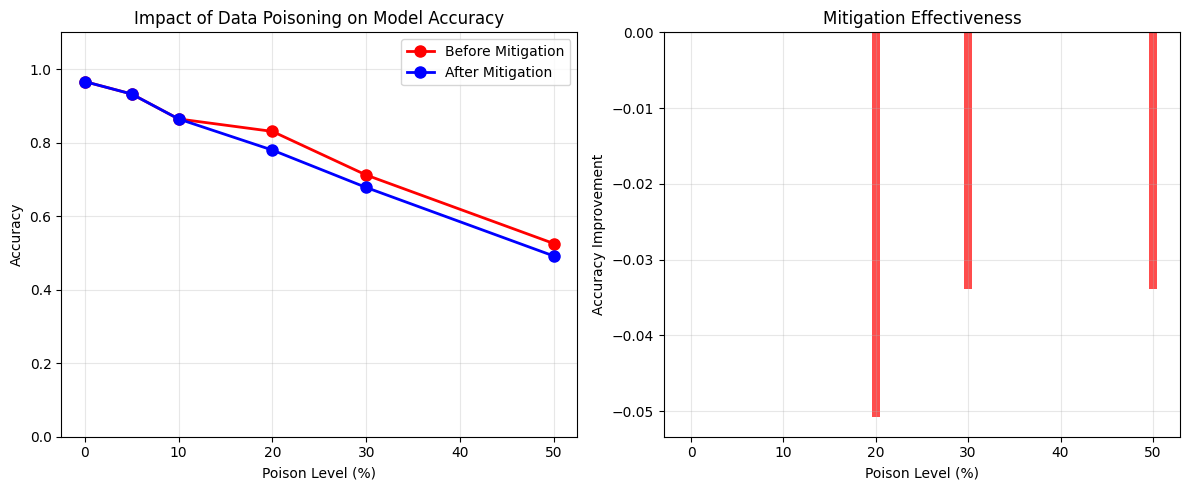

In [10]:
plt.figure(figsize=(12, 5))

# Plot 1: Accuracy vs Poison Level
plt.subplot(1, 2, 1)
plt.plot(poison_levels, accuracies_before, 'ro-', label='Before Mitigation', linewidth=2, markersize=8)
plt.plot(poison_levels, accuracies_after, 'bo-', label='After Mitigation', linewidth=2, markersize=8)
plt.xlabel('Poison Level (%)')
plt.ylabel('Accuracy')
plt.title('Impact of Data Poisoning on Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)

# Plot 2: Accuracy Improvement
plt.subplot(1, 2, 2)
improvements = [acc_after - acc_before for acc_after, acc_before in zip(accuracies_after, accuracies_before)]
colors = ['green' if imp >= 0 else 'red' for imp in improvements]
plt.bar(poison_levels, improvements, color=colors, alpha=0.7)
plt.xlabel('Poison Level (%)')
plt.ylabel('Accuracy Improvement')
plt.title('Mitigation Effectiveness')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()